<a href="https://colab.research.google.com/github/AIDE-00001/Portafolio/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción
---
Para iniciar tu análisis, necesitarás importar los datos de la API de Telecom X. Estos datos están disponibles en formato JSON y contienen información esencial sobre los clientes, incluyendo datos demográficos, tipo de servicio contratado y estado de evasión.

📌 Enlace de la API:
🔗 [challenge2-data-science-LATAM/TelecomX_Data.json at main · ingridcristh/challenge2-data-science-LATAM](https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json)

🔗[GitHub - ingridcristh/challenge2-data-science-LATAM](https://github.com/ingridcristh/challenge2-data-science-LATAM)

¿Qué debes hacer?

✅ Cargar los datos directamente desde la API utilizando Python.

✅ Convertir los datos a un DataFrame de Pandas para facilitar su manipulación.

Este es el primer paso para transformar los datos en información valiosa. ¿Listo para programar? 🚀

In [494]:
import pandas as pd


In [495]:
datos = pd.read_json('/content/TelecomX_Data.json')


In [496]:
df = pd.DataFrame(datos)


In [497]:
df = pd.json_normalize(df.to_dict(orient='records'))

In [498]:
df.head(3)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


#🔧 Transformación

## Conoce el conjunto de datos
---
Ahora que has extraído los datos, es fundamental comprender la estructura del dataset y el significado de sus columnas. Esta etapa te ayudará a identificar qué variables son más relevantes para el análisis de evasión de clientes.

📌 Para facilitar este proceso, hemos creado un diccionario de datos con la descripción de cada columna. Aunque no es obligatorio utilizarlo, puede ayudarte a comprender mejor la información disponible.

🔗 Enlace al diccionario y a la API

¿Qué debes hacer?

✅ Explorar las columnas del dataset y verificar sus tipos de datos.

✅ Consultar el diccionario para comprender mejor el significado de las variables.

✅ Identificar las columnas más relevantes para el análisis de evasión.

📌 Tips:
🔗 [Documentación de DataFrame.info()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html)

🔗 [Documentación de DataFrame.dtypes](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html)

In [499]:
df.columns = df.columns.str.replace('.', '_')

In [500]:
df = df.copy()
df

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [501]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [502]:
df.dtypes

,0
customerID,object
Churn,object
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,object
customer_Dependents,object
customer_tenure,int64
phone_PhoneService,object
phone_MultipleLines,object
internet_InternetService,object


In [503]:
df['account_Charges_Total']

,account_Charges_Total
0,593.3
1,542.4
2,280.85
3,1237.85
4,267.4
...,...
7262,742.9
7263,1873.7
7264,92.75
7265,4627.65


In [504]:
df['Churn'].sample(5)

,Churn
3605,No
979,Yes
7109,No
6735,No
5095,No


In [505]:
df['customer_tenure']

,customer_tenure
0,9
1,9
2,4
3,13
4,3
...,...
7262,13
7263,22
7264,2
7265,67


In [506]:
df[['account_Charges_Monthly', 'account_Charges_Total']]

,account_Charges_Monthly,account_Charges_Total
0,65.60,593.3
1,59.90,542.4
2,73.90,280.85
3,98.00,1237.85
4,83.90,267.4
...,...,...
7262,55.15,742.9
7263,85.10,1873.7
7264,50.30,92.75
7265,67.85,4627.65


In [507]:
df['account_Contract']

,account_Contract
0,One year
1,Month-to-month
2,Month-to-month
3,Month-to-month
4,Month-to-month
...,...
7262,One year
7263,Month-to-month
7264,Month-to-month
7265,Two year


In [508]:
df['account_PaymentMethod']

,account_PaymentMethod
0,Mailed check
1,Mailed check
2,Electronic check
3,Electronic check
4,Mailed check
...,...
7262,Mailed check
7263,Electronic check
7264,Mailed check
7265,Mailed check


In [509]:
df[['internet_InternetService',
       'internet_OnlineSecurity', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies']]

,internet_InternetService,internet_OnlineSecurity,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies
0,DSL,No,Yes,Yes,No
1,DSL,No,No,No,Yes
2,Fiber optic,No,No,No,No
3,Fiber optic,No,No,Yes,Yes
4,Fiber optic,No,Yes,Yes,No
...,...,...,...,...,...
7262,DSL,Yes,Yes,No,No
7263,Fiber optic,No,No,No,Yes
7264,DSL,No,No,No,No
7265,DSL,Yes,Yes,No,Yes


In [510]:
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [511]:
df[[ 'customer_gender','customer_SeniorCitizen','customer_Partner','customer_Dependents']]

,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents
0,Female,0,Yes,Yes
1,Male,0,No,No
2,Male,0,No,No
3,Male,1,Yes,No
4,Female,1,Yes,No
...,...,...,...,...
7262,Female,0,No,No
7263,Male,0,Yes,No
7264,Male,0,No,No
7265,Male,0,Yes,Yes


### Comprobación de incoherencias en los datos
---
En este paso, verifica si hay problemas en los datos que puedan afectar el análisis. Presta atención a valores ausentes, duplicados, errores de formato e inconsistencias en las categorías. Este proceso es esencial para asegurarte de que los datos estén listos para las siguientes etapas.

**Tips:**

* pandas.unique()
* pandas.Series.dt.normalize()

In [512]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [513]:
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [514]:
df['account_Contract'].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [515]:
df['internet_InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [516]:
df['customer_gender'].unique()

array(['Female', 'Male'], dtype=object)

In [517]:
df['account_Contract'].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [518]:
df[['customer_tenure','account_Charges_Monthly','account_Charges_Total']].describe()

,customer_tenure,account_Charges_Monthly
count,7267.000000,7267.000000
mean,32.346498,64.720098
std,24.571773,30.129572
min,0.000000,18.250000
25%,9.000000,35.425000
50%,29.000000,70.300000
75%,55.000000,89.875000
max,72.000000,118.750000


### Manejo de inconsistencias
---Ahora que has identificado las inconsistencias, es momento de aplicar las correcciones necesarias. Ajusta los datos para asegurarte de que estén completos y coherentes, preparándolos para las siguientes etapas del análisis.

In [519]:
df['Churn'].isnull().sum()

np.int64(0)

In [520]:
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')


In [521]:
df['customer_SeniorCitizen'] = df['customer_SeniorCitizen'].astype(int)

In [522]:
df.dtypes

,0
customerID,object
Churn,object
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,object
customer_Dependents,object
customer_tenure,int64
phone_PhoneService,object
phone_MultipleLines,object
internet_InternetService,object


### Columna de cuentas diarias
---
Ahora que los datos están limpios, es momento de crear la columna "Cuentas_Diarias". Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

In [523]:
df['Cuentas_Diarias'] = (df['account_Charges_Monthly'] / 30).round(2)

In [524]:
df[['account_Charges_Monthly','Cuentas_Diarias']].head(2)

,account_Charges_Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00


In [525]:
(df['Cuentas_Diarias'].describe()).round(2)

,Cuentas_Diarias
count,7267.00
mean,2.16
std,1.00
min,0.61
25%,1.18
50%,2.34
75%,3.00
max,3.96


### Estandarización y transformación de datos
---
La estandarización y transformación de datos es una etapa opcional, pero altamente recomendada, ya que busca hacer que la información sea más consistente, comprensible y adecuada para el análisis. Durante esta fase, por ejemplo, puedes convertir valores textuales como "Sí" y "No" en valores binarios (1 y 0), lo que facilita el procesamiento matemático y la aplicación de modelos analíticos.

Además, traducir o renombrar columnas y datos hace que la información sea más accesible y fácil de entender, especialmente cuando se trabaja con fuentes externas o términos técnicos. Aunque no es un paso obligatorio, puede mejorar significativamente la claridad y comunicación de los resultados, facilitando la interpretación y evitando confusiones, especialmente al compartir información con stakeholders no técnicos.

In [528]:
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [529]:
import numpy as np

df['Churn'] = df['Churn'].replace('', np.nan)

In [530]:
df['Churn'].isnull().sum()

np.int64(224)

In [531]:
df = df.dropna(subset=['Churn'])

In [532]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

/tmp/ipykernel_470/4069049957.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [533]:
df['Churn'].unique()

array([0, 1])

In [536]:
df['customer_Partner'].unique()

array(['Yes', 'No'], dtype=object)

In [537]:
df['customer_Partner'] = df['customer_Partner'].map({'Yes': 1, 'No': 0})

/tmp/ipykernel_470/1707519398.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['customer_Partner'] = df['customer_Partner'].map({'Yes': 1, 'No': 0})


In [538]:
df['customer_Partner'].unique()

array([1, 0])

In [541]:
df['customer_Dependents'] = df['customer_Dependents'].map({'Yes': 1, 'No': 0})

/tmp/ipykernel_470/1133884340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['customer_Dependents'] = df['customer_Dependents'].map({'Yes': 1, 'No': 0})


In [540]:
df['customer_Dependents'].unique()

array(['Yes', 'No'], dtype=object)

In [542]:
df['customer_Dependents'].unique()

array([1, 0])

In [544]:
df['phone_PhoneService'].unique()

array(['Yes', 'No'], dtype=object)

In [545]:
df['phone_PhoneService'] = df['phone_PhoneService'].map({'Yes': 1, 'No': 0})

/tmp/ipykernel_470/612531613.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['phone_PhoneService'] = df['phone_PhoneService'].map({'Yes': 1, 'No': 0})


In [546]:
df['phone_PhoneService'].unique()

array([1, 0])

In [548]:
df['account_PaperlessBilling'].unique()

array(['Yes', 'No'], dtype=object)

In [549]:
df['account_PaperlessBilling'] = df['account_PaperlessBilling'].map({'Yes': 1, 'No': 0})

/tmp/ipykernel_470/1468230412.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['account_PaperlessBilling'] = df['account_PaperlessBilling'].map({'Yes': 1, 'No': 0})


In [550]:
df['account_PaperlessBilling'].unique()

array([1, 0])

In [552]:
df.replace({
    'No internet service': 'No',
    'No phone service': 'No'
}, inplace=True)

/tmp/ipykernel_470/2424074369.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.replace({


In [551]:
df.dtypes

,0
customerID,object
Churn,int64
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,int64
customer_Dependents,int64
customer_tenure,int64
phone_PhoneService,int64
phone_MultipleLines,object
internet_InternetService,object


#📊 Carga y análisis

### Análisis Descriptivo
---
Para comenzar, realiza un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

In [554]:
(df.describe()).round(2)

,Churn,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,account_PaperlessBilling,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.0,7043.00,7043.00,7032.00,7043.00
mean,0.27,0.16,0.48,0.30,32.37,0.9,0.59,64.76,2283.30,2.16
std,0.44,0.37,0.50,0.46,24.56,0.3,0.49,30.09,2266.77,1.00
min,0.00,0.00,0.00,0.00,0.00,0.0,0.00,18.25,18.80,0.61
25%,0.00,0.00,0.00,0.00,9.00,1.0,0.00,35.50,401.45,1.18
50%,0.00,0.00,0.00,0.00,29.00,1.0,1.00,70.35,1397.48,2.34
75%,1.00,0.00,1.00,1.00,55.00,1.0,1.00,89.85,3794.74,2.99
max,1.00,1.00,1.00,1.00,72.00,1.0,1.00,118.75,8684.80,3.96


In [556]:
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total', 'Cuentas_Diarias'],
      dtype='object')

In [565]:
columnas_numericas =['customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total', 'Cuentas_Diarias']
df[columnas_numericas].describe().round(2)

,customer_tenure,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
count,7043.00,7043.00,7032.00,7043.00
mean,32.37,64.76,2283.30,2.16
std,24.56,30.09,2266.77,1.00
min,0.00,18.25,18.80,0.61
25%,9.00,35.50,401.45,1.18
50%,29.00,70.35,1397.48,2.34
75%,55.00,89.85,3794.74,2.99
max,72.00,118.75,8684.80,3.96


In [567]:
df[columnas_numericas].median().round(2)

,0
customer_tenure,29.00
account_Charges_Monthly,70.35
account_Charges_Total,1397.48
Cuentas_Diarias,2.34


In [569]:
# Varianza
df[columnas_numericas].var().round(2)

# Desviación estándar
df[columnas_numericas].std().round(2)

,0
customer_tenure,24.56
account_Charges_Monthly,30.09
account_Charges_Total,2266.77
Cuentas_Diarias,1.00


In [570]:
df[columnas_numericas].mode()

,customer_tenure,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
0,1,20.05,20.2,0.66


In [571]:
#Max-min
df[columnas_numericas].max() - df[columnas_numericas].min()

,0
customer_tenure,72.00
account_Charges_Monthly,100.50
account_Charges_Total,8666.00
Cuentas_Diarias,3.35


In [572]:
categoricas = ['Churn', 'account_Contract', 'internet_InternetService']
for col in categoricas:
    print(f"Distribución de {col}:\n", df[col].value_counts(), "\n")

Distribución de Churn:
 Churn
0    5174
1    1869
Name: count, dtype: int64 

Distribución de account_Contract:
 account_Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64 

Distribución de internet_InternetService:
 internet_InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 



In [573]:
for col in categoricas:
    print(f"% de {col}:\n", df[col].value_counts(normalize=True)*100, "\n")

% de Churn:
 Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64 

% de account_Contract:
 account_Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64 

% de internet_InternetService:
 internet_InternetService
Fiber optic    43.958540
DSL            34.374556
No             21.666903
Name: proportion, dtype: float64 



### Distribución de evasión
---
En este paso, el objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes. Utiliza gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

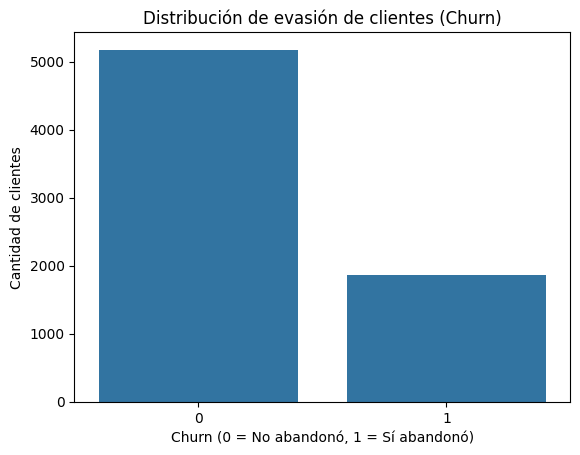

In [574]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df)
plt.title("Distribución de evasión de clientes (Churn)")
plt.xlabel("Churn (0 = No abandonó, 1 = Sí abandonó)")
plt.ylabel("Cantidad de clientes")
plt.show()

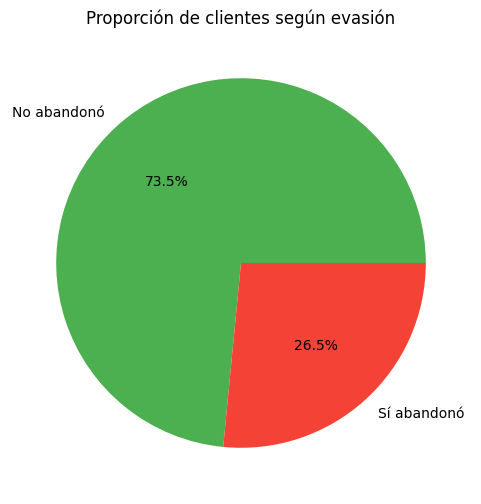

In [575]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=['No abandonó','Sí abandonó'], autopct='%1.1f%%', colors=['#4CAF50','#F44336'])
plt.title("Proporción de clientes según evasión")
plt.show()

### Recuento de evasión por variables categóricas
---
Ahora, exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras.

Este análisis puede revelar patrones interesantes, por ejemplo, si los clientes de ciertos perfiles tienen una mayor tendencia a cancelar el servicio, lo que ayudará a orientar acciones estratégicas.

In [576]:
categoricas = ['customer_gender', 'account_Contract', 'account_PaymentMethod', 'internet_InternetService']

In [577]:
for col in categoricas:
    print(f"\nDistribución de Churn según {col}:")
    print(df.groupby(col)['Churn'].value_counts())


Distribución de Churn según customer_gender:
customer_gender  Churn
Female           0        2549
                 1         939
Male             0        2625
                 1         930
Name: count, dtype: int64

Distribución de Churn según account_Contract:
account_Contract  Churn
Month-to-month    0        2220
                  1        1655
One year          0        1307
                  1         166
Two year          0        1647
                  1          48
Name: count, dtype: int64

Distribución de Churn según account_PaymentMethod:
account_PaymentMethod      Churn
Bank transfer (automatic)  0        1286
                           1         258
Credit card (automatic)    0        1290
                           1         232
Electronic check           0        1294
                           1        1071
Mailed check               0        1304
                           1         308
Name: count, dtype: int64

Distribución de Churn según internet_InternetService

In [578]:
for col in categoricas:
    print(f"\n% de Churn según {col}:")
    print(df.groupby(col)['Churn'].value_counts(normalize=True) * 100)


% de Churn según customer_gender:
customer_gender  Churn
Female           0        73.079128
                 1        26.920872
Male             0        73.839662
                 1        26.160338
Name: proportion, dtype: float64

% de Churn según account_Contract:
account_Contract  Churn
Month-to-month    0        57.290323
                  1        42.709677
One year          0        88.730482
                  1        11.269518
Two year          0        97.168142
                  1         2.831858
Name: proportion, dtype: float64

% de Churn según account_PaymentMethod:
account_PaymentMethod      Churn
Bank transfer (automatic)  0        83.290155
                           1        16.709845
Credit card (automatic)    0        84.756899
                           1        15.243101
Electronic check           0        54.714588
                           1        45.285412
Mailed check               0        80.893300
                           1        19.106700
Name: pr

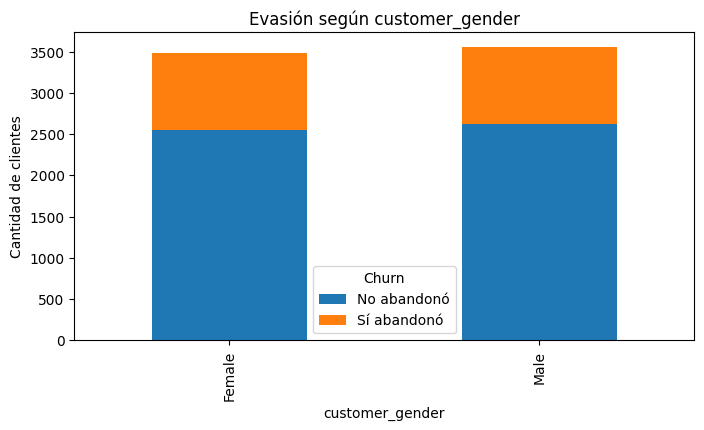

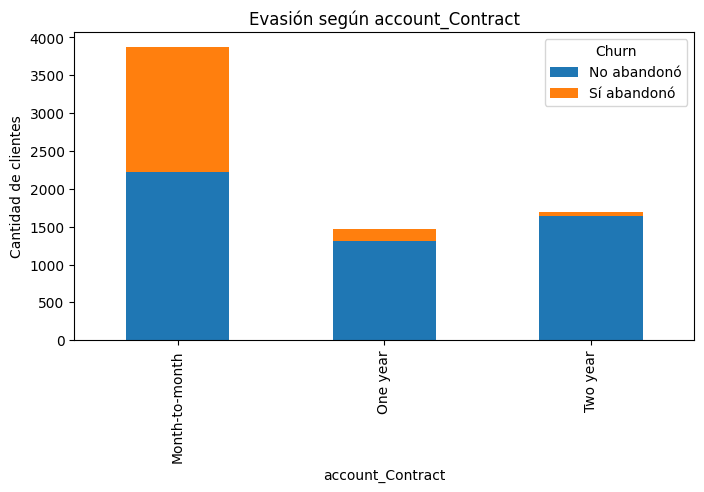

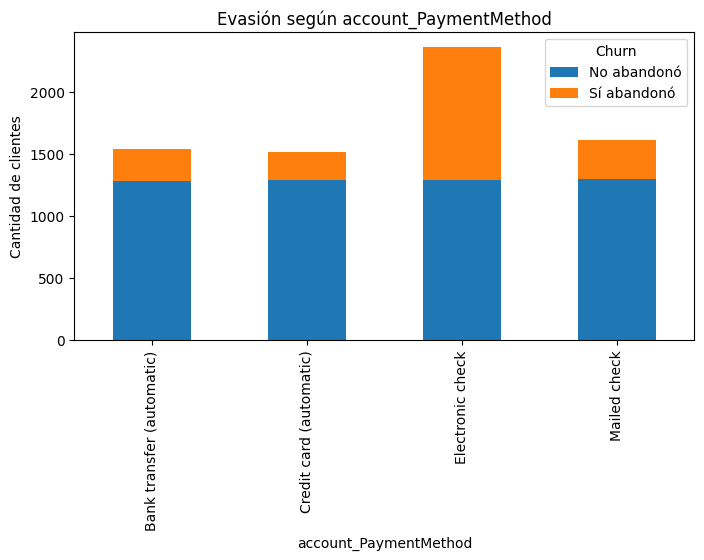

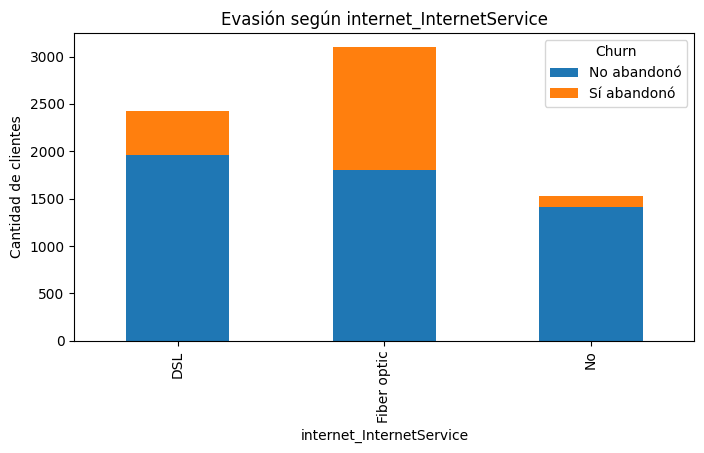

In [579]:
for col in categoricas:
    pd.crosstab(df[col], df['Churn']).plot(kind='bar', stacked=True, figsize=(8,4))
    plt.title(f"Evasión según {col}")
    plt.xlabel(col)
    plt.ylabel("Cantidad de clientes")
    plt.legend(title='Churn', labels=['No abandonó','Sí abandonó'])
    plt.show()

#📄Informe final

### Finaliza el desafío elaborando un informe dentro del mismo notebook que resuma todo el trabajo realizado. El informe debe incluir:

🔹 Introducción: Explica el objetivo del análisis y el problema de evasión de clientes (Churn).

🔹 Limpieza y Tratamiento de Datos: Describe los pasos realizados para importar, limpiar y procesar los datos.

🔹 Análisis Exploratorio de Datos: Presenta los análisis realizados, incluyendo gráficos y visualizaciones para identificar patrones.

🔹 Conclusiones e Insights: Resume los principales hallazgos y cómo estos datos pueden ayudar a reducir la evasión.

🔹 Recomendaciones: Ofrece sugerencias estratégicas basadas en tu análisis.

Asegúrate de que el informe esté bien estructurado, claro y respaldado por visualizaciones que refuercen tus conclusiones.

### INFORME
---
El **objetivo** de este análisis es estudiar el problema de evasión de clientes `Churn`` de Telecom X se sabe que la vasión de clientes representa un **riesgo importante** para la empresa, ya que impacta directamente en los ingresos y la estabilidad del negocio.

En este análisis se busca comprender el comportamiento de los clientes, identificar patrones de abandono y generar hallasgos que permitan diseñar estrategias de retención.

Se cargaron los datos desde la API en formato JSON y se convirtieron a un DataFrame con ayuda de Pandas, se vieron las columnas y los tipos de de datos, que valores se tenian.

Encontramos ``Churn` tenia valores nulos por lo que se debieron eliminar, también en `'account_Charges_Total'` se encontraba en tipo de dato como object lo cual se paso dato numerico entre otros más

Las columnas que tenian como respuesta `si` y `no` se cambiaron a 0 y 1.

Se calcularon métricas estadísticas clave de las variables numéricas: media, mediana, desviación estándar, varianza, rango y moda.
Además, se revisaron las distribuciones de variables categóricas.

Se visualizó la proporción de clientes que permanecen vs los que se dieron de baja.
Tambien se visualizo la evasipn de variables categoricas

Para insentivar a los clientes se podria dar descuentos dependiendiendo el tipo de contrato que tengan para que se animen a continuar y no abandonar
Cuando los clientes son nuevos tratar de ver tener más cuidado sobre posibles alertas de baja evitado el riesgo de churn
